In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
from functools import partial

import torch
import torch.nn as nn
from lightning.pytorch import LightningModule, LightningDataModule, Trainer, seed_everything

from src.models_cloudsat_masked import GeoCloudSatMaskedTransformer
from src.dataloaders import GeoCloudsatDataloader

/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
import pathlib
data_path = pathlib.Path("./data/cloudsat-goes-paired/")
files = sorted(list(data_path.glob("*.nc")))
len(files)

3000

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import torch

from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, ExponentialLR
from torchvision.utils import _log_api_usage_once
from lightning.pytorch import LightningModule, LightningDataModule, Trainer, seed_everything
from lightning.pytorch.callbacks import TQDMProgressBar
from lightning.pytorch.loggers import CSVLogger
from tqdm import tqdm

In [4]:
class LitProgressBar(TQDMProgressBar):
    def init_validation_tqdm(self):
        bar = tqdm(            
            disable=True,            
        )
        return bar

# Add a logger for metrics and checkpoints
csv_logger = CSVLogger(
    save_dir='',
    name='logs'
)

In [5]:
class GeoMaskedCloudsat(LightningModule):
    def __init__(self, *args, **kwargs):
        super().__init__()
        self.model = GeoCloudSatMaskedTransformer(*args, **kwargs)

    def forward(self, batch):
        return self.model.forward(*batch)

    def training_step(self, batch, batch_idx):
        loss = self.model.forward_loss(*batch)
        # log training loss
        self.log(
            "train_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self.model.forward_loss(*batch)
        # log validation loss
        self.log(
            "val_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss

    def test_step(self, batch, batch_idx):
        loss = self.model.forward_loss(*batch)
        # log test loss
        self.log(
            "test_loss", loss, on_step=True, on_epoch=True, logger=True, prog_bar=True
        )
        return loss
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=5e-4)

        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": ExponentialLR(optimizer, gamma=0.95)}
            # "lr_scheduler": {
            #     "scheduler": ReduceLROnPlateau(optimizer),
            #     "patience": 10,
            #     "interval": "epoch",
            #     "monitor": "val_loss",
            #     "frequency": 1,
            # },
        }

In [6]:
GeoCloudSatMaskedTransformer?

Init signature:
GeoCloudSatMaskedTransformer(
    *args,
    output_dim=125,
    prediction_head=None,
    **kwargs,
)
Docstring:     
GeoMAE based on ViT-5 with LayerScale (https://arxiv.org/abs/2103.17239) support
taken from https://github.com/rwightman/pytorch-image-models/blob/master/timm/models/vision_transformer.py
with slight modifications
Init docstring: Initialize internal Module state, shared by both nn.Module and ScriptModule.
File:           ~/python/transformer_model_experiments/src/models_cloudsat_masked.py
Type:           type
Subclasses:     

In [7]:
_ = seed_everything(42)

dl = GeoCloudsatDataloader(16, files)

model = GeoMaskedCloudsat(
    in_chans=16,
    img_size=256, 
    patch_size=16, 
    embed_dim=768, 
    depth=12,
    num_heads=12,
    decoder_embed_dim=768,
    decoder_depth=12, 
    decoder_num_heads=12,
    mlp_ratio=4.,
    num_coords=2,
    coord_limits=[
        [1  / (2*np.pi), 360 / (2*np.pi)], # longitude 1->360 degrees
        [1  / (2*np.pi), 360 / (2*np.pi)], # latitude 1->360 degrees
    ],
)

# model = torch.compile(model)

Seed set to 42


In [8]:
# Initialize the trainer
trainer = Trainer(
    max_epochs=20,
    callbacks=[LitProgressBar()],
    logger=csv_logger,
    accelerator="auto",
    accumulate_grad_batches=1,
)

trainer.fit(model, dl)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GeoCloudSatMaskedTransformer │  177 M │ train │     0 │
└───┴───────┴──────────────────────────────┴────────┴───────┴───────┘

Trainable params: 177 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 177 M                                                                                                
Total estimated model params size (MB): 708                                                                        
Modules in train mode: 445                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |                                                                                          | 0/? [00:00<?, ?it/s]

/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Epoch 19: 100%|█| 132/132 [06:37<00:00,  0.33it/s, v_num=48, train_loss_step=9.880, val_loss_step=4.170, val_loss_epoch=15.20, tra

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|█| 132/132 [06:39<00:00,  0.33it/s, v_num=48, train_loss_step=9.880, val_loss_step=4.170, val_loss_epoch=15.20, tra


In [10]:
_ = model.eval()

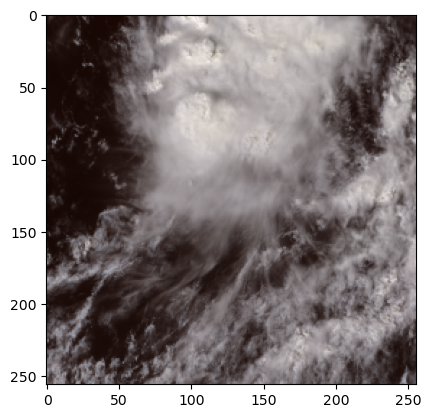

In [11]:
plt.imshow(dl.train_dataset[300][0].transpose(1,2,0)[...,:3])

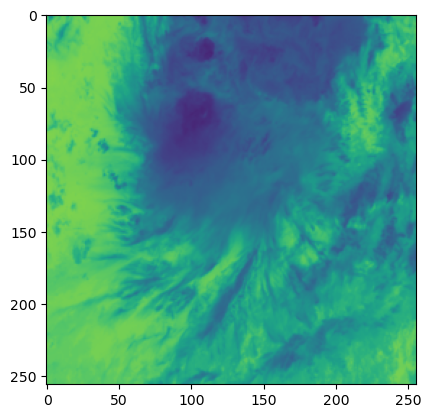

In [12]:
plt.imshow(dl.train_dataset[300][0].transpose(1,2,0)[...,-4], vmin=0, vmax=1)
# plt.colorbar()

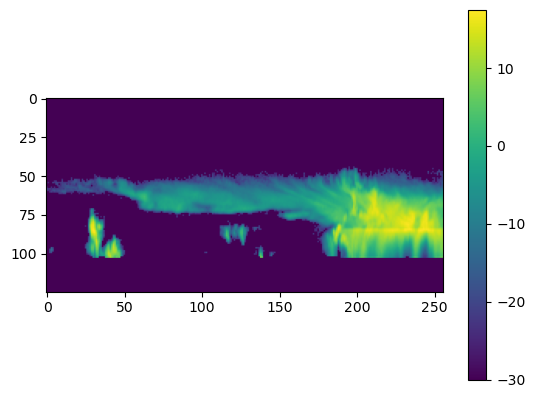

In [13]:
plt.imshow(dl.train_dataset[300][2].T)
plt.colorbar()

In [14]:
batch = [
    torch.tensor(arr[np.newaxis]) for arr in dl.train_dataset[300]
]
test = model.model.forward(
    batch[0], batch[1], batch[3], 
).detach().numpy()

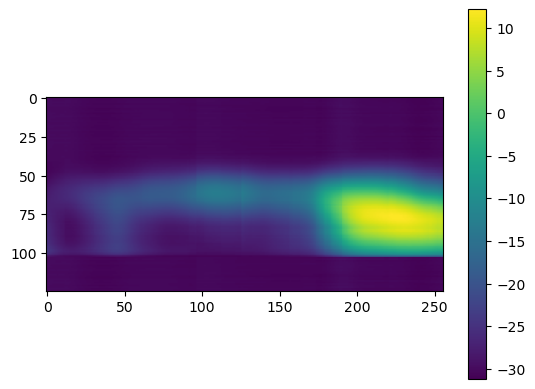

In [15]:
plt.imshow(test[0].T)
plt.colorbar()

In [16]:
test = model.model.forward(
    batch[0], batch[1], batch[1][...,128].reshape(1,2,-1)
).detach().numpy()[0]

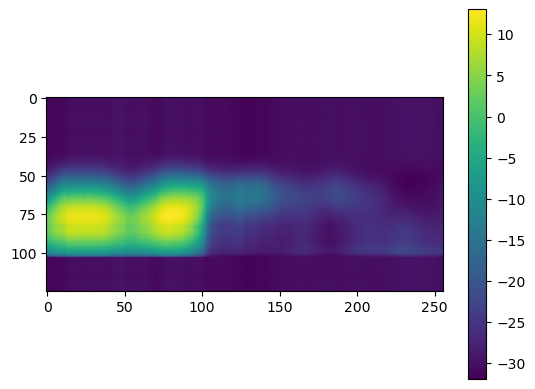

In [17]:
plt.imshow(test.T)
plt.colorbar()

In [18]:
batch[1].shape

torch.Size([1, 2, 256, 256])

In [19]:
test_grid = model.model.forward(
    batch[0], batch[1], batch[1][...,32:224,32:224].reshape(1,2,-1)
).detach().numpy()[0].reshape(192,192,125)

In [20]:
test_grid.shape

(192, 192, 125)

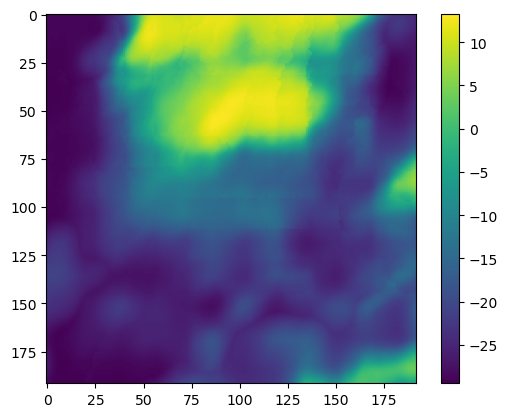

In [21]:
plt.imshow(test_grid.max(-1))
plt.colorbar()

Limiting the number of attention columns works better!